XTrain2
Item 1/1:
     Patient_Id Exercise_Id                                  Skeleton_Sequence
0             1          E1  [[-0.003837984, -0.579281688, 0.010213038, -0....
1             1          E1  [[-0.006423568, -0.590631604, 0.007034406, -0....
2             1          E1  [[0.010297444, -0.57850194, 0.023338385, -0.60...
3             1          E1  [[-0.039400429, -0.541313469, -0.023210142, -0...
4             2          E1  [[0.002523404, -0.574687421, 0.021674899, -0.5...
..          ...         ...                                                ...
441          14          E5  [[0.018183682, -0.503416181, 0.036054168, -0.5...
442          14          E5  [[0.008919089, -0.529203534, 0.022257812321186...
443          14          E5  [[0.046009932, -0.537010968, 0.060299847, -0.5...
444          14          E5  [[0.034558345, -0.547864616, 0.049173623, -0.5...
445          14          E5  [[0.00171333, -0.546153963, 0.0175316613167524...
[446 rows x 3 columns]

YTrain2
shape: (14,)
[0 0 0 0 1 1 1 0 0 0 0 1 0 1]

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

CLASS_NAME = {
    0: "Left",
    1: "Right",
}

In [3]:
# Load data
X1 = pd.read_pickle("Xtrain2.pkl")
y = np.load("Ytrain2.npy")

Patients = np.stack(X1["Patient_Id"].values)
Exercises = np.stack(X1["Exercise_Id"].values)
Classes = np.stack([y[patient-1] for patient in Patients])




In [4]:

# Check the type and shape of the first Skeleton_Sequence entry
sample = X1.iloc[0]['Skeleton_Sequence']
print("Type:", type(sample))
arr = np.array(sample)
print("Array shape:", arr.shape)
print("First frame:", arr[0])
print("First frame shape:", np.array(arr[0]).shape)

Type: <class 'numpy.ndarray'>
Array shape: (205, 66)
First frame: [-3.83798400e-03 -5.79281688e-01  1.02130380e-02 -6.03365481e-01
  1.46907010e-02 -6.02224231e-01  1.21108160e-02 -6.02247417e-01
 -1.13773300e-02 -6.05828226e-01 -8.19435700e-03 -6.04369819e-01
 -2.47284600e-03 -5.95960736e-01  7.25424510e-02 -5.77429533e-01
 -6.13183160e-02 -5.29787838e-01  3.62115870e-02 -5.67890882e-01
  5.42236300e-03 -5.30614913e-01  1.92643166e-01 -4.11808223e-01
 -1.46626949e-01 -4.67117280e-01  2.55298257e-01 -2.07626253e-01
 -2.54153132e-01 -2.08918810e-01  1.84073254e-01 -2.62119230e-02
 -2.13687733e-01 -3.78842240e-02  1.53919771e-01  1.46083560e-02
 -1.68415293e-01  2.03120200e-03  1.10407449e-01  2.09811000e-03
 -1.19227938e-01 -4.21764250e-02  1.64255336e-01 -4.42582600e-03
 -1.86335668e-01 -4.16434930e-02  1.02769226e-01  1.93887000e-04
 -1.00737363e-01 -2.02842000e-03  2.75885463e-01  1.86499149e-01
 -1.33297220e-01  1.24749184e-01  2.23359361e-01  5.82396865e-01
 -1.56935722e-01  5.5636

In [11]:
unique, counts = np.unique(y, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {CLASS_NAME[u]}: {c} samples")

Class Left: 9 samples
Class Right: 5 samples


Exercise Count for each patient

In [ ]:
for patient in np.unique(Patients):
    print(f"\nPatient ID: {patient}")

    patient_indices = np.where(Patients == patient)[0]
    patient_exercises = Exercises[patient_indices]
    
    unique_exercises, exercise_counts = np.unique(patient_exercises, return_counts=True)
    for ex, count in zip(unique_exercises, exercise_counts):
        print(f"  Exercise {ex}: {count} samples")

Impairment distribution for each exercise

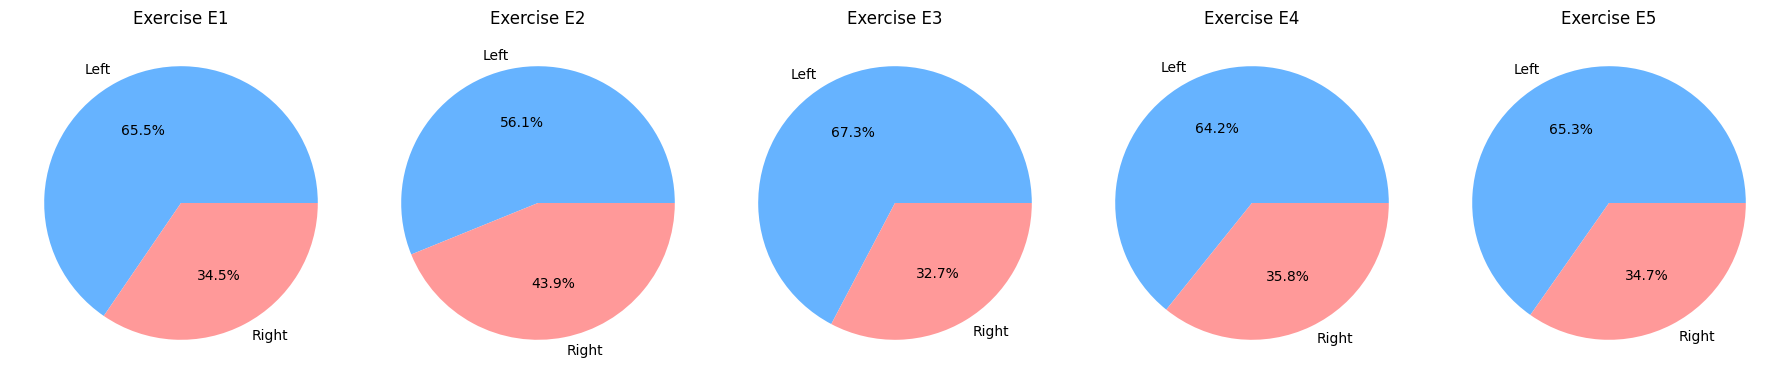

In [28]:
# Pie charts for class distribution per exercise
exercise_ids = np.unique(Exercises)
fig, axes = plt.subplots(1, len(exercise_ids), figsize=(18, 4))

for idx, ex_id in enumerate(exercise_ids):
    ex_indices = np.where(Exercises == ex_id)[0]
    ex_classes = Classes[ex_indices]
    class_counts = [np.sum(ex_classes == 0), np.sum(ex_classes == 1)]
    axes[idx].pie(class_counts, labels=[CLASS_NAME[0], CLASS_NAME[1]], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
    axes[idx].set_title(f'Exercise {ex_id}')

plt.tight_layout()
plt.show()

In [ ]:
means = np.zeros((len(X1), 33, 2))
stds = np.zeros((len(X1), 33, 2))
avg_speeds = np.zeros((len(X1), 33))
travels = np.zeros((len(X1), 33)) 

for i, sequence in enumerate(X1['Skeleton_Sequence'].values):
    sequence_array = np.array(sequence)
    sequence_array = sequence_array.reshape(-1, 33, 2)

    means[i] = np.mean(sequence_array, axis=0)   
    stds[i] = np.std(sequence_array, axis=0)
    avg_speeds[i] = np.mean(np.linalg.norm(np.diff(sequence_array, axis=0), axis=2), axis=0)
    travels[i] = np.sum(np.linalg.norm(np.diff(sequence_array, axis=0), axis=2), axis=0)

for i in range(33):
    print(f"KP {i}: Std: {stds[0,i,0]:.4f}, Mean Speed: {avg_speeds[0,i]:.4f}, Travel Distance: {travels[0,i]:.4f}")


KP 0: Mean Speed: 0.0049, Travel Distance: 1.0051
KP 1: Mean Speed: 0.0048, Travel Distance: 0.9708
KP 2: Mean Speed: 0.0048, Travel Distance: 0.9709
KP 3: Mean Speed: 0.0047, Travel Distance: 0.9625
KP 4: Mean Speed: 0.0048, Travel Distance: 0.9751
KP 5: Mean Speed: 0.0048, Travel Distance: 0.9742
KP 6: Mean Speed: 0.0048, Travel Distance: 0.9735
KP 7: Mean Speed: 0.0044, Travel Distance: 0.9025
KP 8: Mean Speed: 0.0045, Travel Distance: 0.9207
KP 9: Mean Speed: 0.0046, Travel Distance: 0.9360
KP 10: Mean Speed: 0.0046, Travel Distance: 0.9352
KP 11: Mean Speed: 0.0038, Travel Distance: 0.7679
KP 12: Mean Speed: 0.0039, Travel Distance: 0.7991
KP 13: Mean Speed: 0.0051, Travel Distance: 1.0476
KP 14: Mean Speed: 0.0052, Travel Distance: 1.0701
KP 15: Mean Speed: 0.0052, Travel Distance: 1.0606
KP 16: Mean Speed: 0.0073, Travel Distance: 1.4960
KP 17: Mean Speed: 0.0055, Travel Distance: 1.1205
KP 18: Mean Speed: 0.0083, Travel Distance: 1.6999
KP 19: Mean Speed: 0.0060, Travel Distanc

Plot one frame

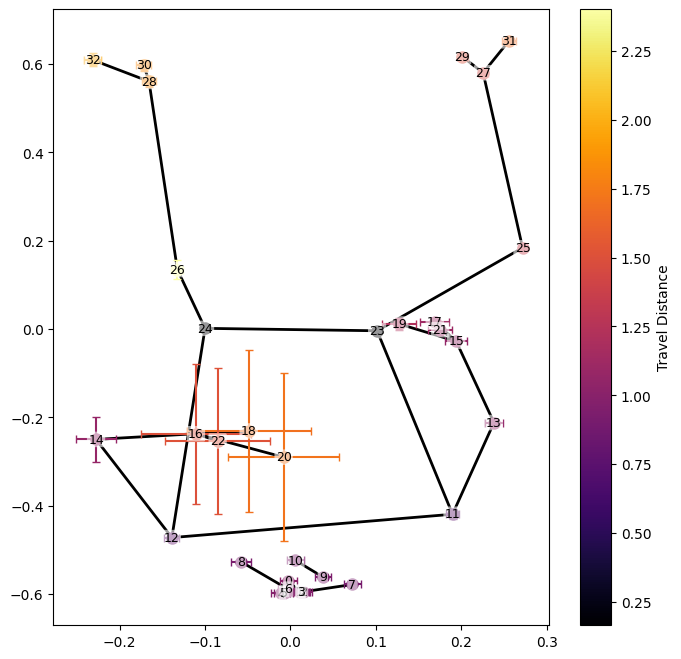

In [33]:
# Define skeleton edges (from your skeleton.png)
skeleton_edges = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),
    (11,12),(11,23),(12,24),(23,24),
    (11,13),(13,15),(15,17),(15,19),(15,21),
    (12,14),(14,16),(16,18),(16,20),(16,22),
    (23,25),(25,27),(27,29),(27,31),
    (24,26),(26,28),(28,30),(28,32)
]

plt.figure(figsize=(8, 8))
ax = plt.gca()  # Get current axes

id = 0  # sample index to plot

from matplotlib import cm
norm = plt.Normalize(travels[id].min(), travels[id].max())
cmap = cm.inferno

for kp in range(33):
    color = cmap(norm(travels[id, kp]))
    plt.errorbar(
        means[id, kp, 0], means[id, kp, 1],
        xerr=stds[id, kp, 0], yerr=stds[id, kp, 1],
        fmt='o', color=color, ecolor=color, capsize=3, markersize=8
    )
    plt.text(
        means[id, kp, 0], means[id, kp, 1], str(kp), fontsize=9, ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, boxstyle='round,pad=0.1')
    )
# Skeleton Edges
for (i, j) in skeleton_edges:
    plt.plot([means[id, i, 0], means[id, j, 0]], [means[id, i, 1], means[id, j, 1]], 'k-', linewidth=2, zorder=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label='Travel Distance', ax=ax)  # <-- Pass ax here

plt.show()